# VibeShift — Inference

Latent-in / Audio-out genre transfer using a trained FlowMatching checkpoint.

**Pipeline:** DAC latent file → Flow matching → DAC decode → Playback

| Cell | Purpose |
|------|---------|
| 1 | Setup (sys.path, imports) |
| 2 | Configuration — set paths here |
| 3 | Load flow model from checkpoint |
| 4 | Load DAC codec |
| 5 | Load DAC latent from file |
| 6 | Run inference (Euler / Heun) |
| 7 | Decode latent to audio + playback |
| 8 | Save output audio files |


In [1]:
# Cell 1 — Setup
import sys, os

# Resolve workspace root (works from training/)
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import torchaudio
import soundfile as sf
from IPython.display import Audio, display

import dac
from dac.utils import download as dac_download

from models.dit import DiT
from models.flow import FlowMatching

print(f"ROOT       : {ROOT}")
print(f"PyTorch    : {torch.__version__}")
print(f"CUDA avail : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU        : {props.name}  ({props.total_memory / 1e9:.1f} GB)")


film_conditioner.py STARTED
ROOT       : c:\Users\Dhanuja\Downloads\VibeShift-main\VibeShift-main
PyTorch    : 2.9.0+cpu
CUDA avail : False


## Configuration

Edit Cell 2 before running anything else.

**CHECKPOINT_PATH** — path to the `.pt` checkpoint (e.g. `best.pt`).

**LATENT_INPUT_PATH** — path to a pre-computed DAC latent file. Supported formats:
- `.npy` — NumPy array of shape `(1, T, D)` or `(T, D)`
- `.pt` — PyTorch tensor of the same shape

**MODEL_CONFIG** — must match the architecture used during training. Defaults match the `synth-to-punk-4090` run.


In [2]:
# Cell 2 — Configuration  (edit all paths here)

# ---- paths ---------------------------------------------------------------
CHECKPOINT_PATH  = r"C:\Users\Dhanuja\Downloads\checkpoints_punk-20260313T155413Z-1-001\checkpoints_punk\best.pt"
LATENT_INPUT_PATH = r"C:\Users\Dhanuja\Downloads\vibe\02035_Spowder_Miracle_Grow_instrumental_chunk013_26000ms_synth.pt"  # .npy (numpy) or .pt (torch tensor), shape (1, T, D) or (T, D)
OUTPUT_DIR       = r"C:\Users\Dhanuja\Downloads\inference_output"

# ---- DAC model (needed for decoding) -------------------------------------
DAC_MODEL_TYPE = "44khz"   # "44khz" | "24khz" | "16khz"
TARGET_SR      = 44100     # must match DAC_MODEL_TYPE

# ---- model architecture (must match training) ----------------------------
MODEL_CONFIG = dict(
    input_dim  = 768,
    embed_dim  = 512,
    num_blocks = 8,
    num_heads  = 8,
    num_genres = 3,
    hidden_dim = 2048,
    dropout    = 0.1,
)

# ---- genre IDs (must match training labels) ------------------------------
# 0 = synth/MIDI source, 1 = punk target  (adjust to your training setup)
TARGET_GENRE_ID = 1

# ---- sampling ------------------------------------------------------------
EULER_STEPS = 50    # Euler integration steps
HEUN_STEPS  = 25    # Heun integration steps (2nd-order, similar quality)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Checkpoint  : {CHECKPOINT_PATH}")
print(f"Latent in   : {LATENT_INPUT_PATH}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Device      : {DEVICE}")


Checkpoint  : C:\Users\Dhanuja\Downloads\checkpoints_punk-20260313T155413Z-1-001\checkpoints_punk\best.pt
Latent in   : C:\Users\Dhanuja\Downloads\vibe\02035_Spowder_Miracle_Grow_instrumental_chunk013_26000ms_synth.pt
Output dir  : C:\Users\Dhanuja\Downloads\inference_output
Device      : cpu


## Load Flow Model

In [3]:
# Cell 3 — Load flow model from checkpoint

ckpt_path = pathlib.Path(CHECKPOINT_PATH)
if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

checkpoint = torch.load(str(ckpt_path), map_location=DEVICE)

dit   = DiT(**MODEL_CONFIG)
model = FlowMatching(dit)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

for p in model.parameters():
    p.requires_grad_(False)

saved_epoch = checkpoint.get("epoch", "unknown")
best_loss   = checkpoint.get("best_loss", float("nan"))
n_params    = sum(p.numel() for p in model.parameters())

print(f"Checkpoint  : {ckpt_path.name}")
print(f"Saved epoch : {saved_epoch}")
print(f"Best loss   : {best_loss:.6f}" if isinstance(best_loss, float) else f"Best loss   : {best_loss}")
print(f"Parameters  : {n_params / 1e6:.2f}M")
print(f"Device      : {DEVICE}")


Checkpoint  : best.pt
Saved epoch : 87
Best loss   : 3.440119
Parameters  : 36.51M
Device      : cpu


## Load DAC Codec

The DAC model is used to encode audio into latent representations and decode them back.
If the model weights are not cached locally they will be downloaded automatically.

In [4]:
# Cell 4 — Load DAC codec

print(f"Loading DAC model ({DAC_MODEL_TYPE})...")
_dac_path = dac_download(model_type=DAC_MODEL_TYPE)
dac_model = dac.DAC.load(_dac_path)
dac_model.to(DEVICE)
dac_model.eval()

for p in dac_model.parameters():
    p.requires_grad_(False)

print(f"DAC model loaded")
print(f"  Sample rate : {dac_model.sample_rate} Hz")
print(f"  Device      : {DEVICE}")


Loading DAC model (44khz)...


c:\Users\Dhanuja\Downloads\VibeShift-main\VibeShift-main\.venv\lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


DAC model loaded
  Sample rate : 44100 Hz
  Device      : cpu


## Load DAC Latent

Loads a pre-computed DAC latent from a `.npy` or `.pt` file.
The latent must have shape `(1, T, D)` or `(T, D)` — it will be reshaped to `(1, T, D)` automatically.


In [11]:
# Cell 5 — Load DAC latent from file

latent_path = pathlib.Path(LATENT_INPUT_PATH)
if not latent_path.exists():
    raise FileNotFoundError(f"Latent file not found: {latent_path}")

suffix = latent_path.suffix.lower()
if suffix == ".npy":
    x0 = torch.from_numpy(np.load(str(latent_path))).float()
    src_codes = None
elif suffix == ".pt":
    raw = torch.load(str(latent_path), map_location="cpu")
    if isinstance(raw, torch.Tensor):
        x0 = raw.float()
        src_codes = None
    elif isinstance(raw, dict):
        print(f"Loaded dict with keys: {list(raw.keys())}")
        # Try common key names for latent tensors
        for key in ("z", "latent", "latents", "x", "x0", "embedding", "features"):
            if key in raw and isinstance(raw[key], torch.Tensor):
                x0 = raw[key].float()
                print(f"Using key '{key}'")
                break
        else:
            tensor_items = [(k, v) for k, v in raw.items() if isinstance(v, torch.Tensor)]
            if not tensor_items:
                raise ValueError(f"No tensor found in dict. Keys: {list(raw.keys())}")
            key, x0 = tensor_items[0]
            x0 = x0.float()
            print(f"No known key found — using first tensor key '{key}'")
        # Also grab discrete codes if present (needed for decoding projected latents)
        src_codes = raw.get("codes", None)
        if src_codes is not None:
            src_codes = src_codes.long()
            print(f"Stored codes shape : {tuple(src_codes.shape)}")
    else:
        raise ValueError(f"Unexpected type in .pt file: {type(raw)}")
else:
    raise ValueError(f"Unsupported latent format '{suffix}'. Use .npy or .pt")

# Ensure shape is (1, T, D)
if x0.ndim == 2:
    x0 = x0.unsqueeze(0)
if x0.ndim != 3:
    raise ValueError(f"Expected latent of shape (T, D) or (1, T, D), got {tuple(x0.shape)}")

x0 = x0.to(DEVICE)

print(f"Loaded latent : {latent_path.name}")
print(f"Shape         : {tuple(x0.shape)}  (batch, time-steps, embedding-dim)")
print(f"Stats         : mean={x0.mean():.4f}  std={x0.std():.4f}  "
      f"min={x0.min():.4f}  max={x0.max():.4f}")


Loaded dict with keys: ['z', 'codes', 'latents', 'sample_rate', 'original_length']
Using key 'z'
Stored codes shape : (1, 9, 567)
Loaded latent : 02035_Spowder_Miracle_Grow_instrumental_chunk013_26000ms_synth.pt
Shape         : (1, 567, 768)  (batch, time-steps, embedding-dim)
Stats         : mean=-0.0242  std=2.2980  min=-9.9688  max=9.7812


## Run Inference

Runs both Euler (1st-order) and Heun (2nd-order) samplers on the DAC latent.
Euler with 50 steps and Heun with 25 steps give comparable quality.

In [12]:
# Cell 6 — Run inference

genre_id = torch.tensor([TARGET_GENRE_ID], device=DEVICE, dtype=torch.long)

with torch.no_grad():
    x_euler = model.sample_euler(x0, genre_id, num_steps=EULER_STEPS)
    x_heun  = model.sample_heun( x0, genre_id, num_steps=HEUN_STEPS)

x_euler = x_euler.float()
x_heun  = x_heun.float()

print(f"Output shape (Euler) : {x_euler.shape}")
print(f"Output shape (Heun)  : {x_heun.shape}")
print()

print("Euler output stats : "
      f"mean={x_euler.mean():.4f}  std={x_euler.std():.4f}  "
      f"min={x_euler.min():.4f}  max={x_euler.max():.4f}")
print("Heun  output stats : "
      f"mean={x_heun.mean():.4f}  std={x_heun.std():.4f}  "
      f"min={x_heun.min():.4f}  max={x_heun.max():.4f}")

disp_euler = (x_euler - x0).abs().mean().item()
disp_heun  = (x_heun  - x0).abs().mean().item()
print()
print(f"Mean abs displacement from source (Euler) : {disp_euler:.6f}")
print(f"Mean abs displacement from source (Heun)  : {disp_heun:.6f}")


Output shape (Euler) : torch.Size([1, 567, 768])
Output shape (Heun)  : torch.Size([1, 567, 768])

Euler output stats : mean=0.0146  std=3.3011  min=-16.2206  max=14.0254
Heun  output stats : mean=0.0141  std=3.2944  min=-16.2041  max=14.0104

Mean abs displacement from source (Euler) : 1.688419
Mean abs displacement from source (Heun)  : 1.681531


## Decode Latent to Audio and Play

Decodes both Euler and Heun outputs through the DAC decoder,
plots the waveforms alongside the source, then renders inline audio players.

Computing pseudo-inverse from stored codes …
  Pseudo-inverse shape : (768, 1024)
Decoding Euler output …
  Projected 768-dim latent → 1024-dim for decoding
Decoding Heun output …
  Projected 768-dim latent → 1024-dim for decoding

Output duration (Euler) : 6.58s  @ 44100 Hz
Output duration (Heun)  : 6.58s  @ 44100 Hz


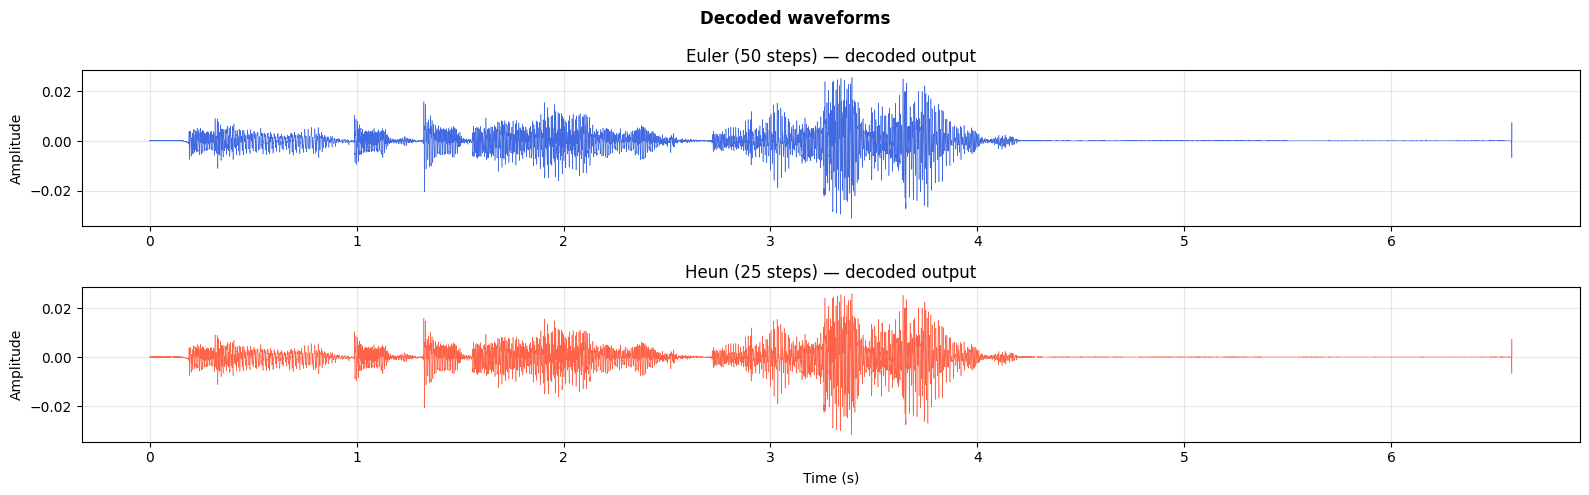


Euler output:



Heun output:


: 

In [ ]:
# Cell 7 — Decode latents to audio + playback

DAC_NATIVE_DIM = 1024  # DAC 44khz decoder expects this channel count

def get_decode_weight(x0_flat: torch.Tensor, codes: torch.Tensor) -> torch.Tensor:
    """
    Compute a data-driven pseudo-inverse W_inv (D_proj, D_native) so that
    x0_flat @ W_inv ≈ z_native reconstructed from the stored RVQ codes.

    This recovers an approximation of the inverse of the random linear
    projection (1024 → D_proj) that was applied when the training latents
    were created. Without the saved projection weights this is the best
    available approach.
    """
    codes = codes.to(DEVICE)                              # (1, n_codebooks, T)
    with torch.no_grad():
        z_native, _, _ = dac_model.quantizer.from_codes(codes)  # (1, 1024, T)
    z_native_t = z_native.permute(0, 2, 1).squeeze(0).float()   # (T, 1024)

    # Minimum-norm lstsq: x0_flat @ W_inv = z_native_t
    # W_inv shape: (D_proj, 1024)
    A = x0_flat  # (T, D_proj)
    B = z_native_t  # (T, 1024)
    W_inv = torch.linalg.pinv(A) @ B   # (D_proj, 1024)
    return W_inv


def decode_latent(lat: torch.Tensor, w_inv: torch.Tensor | None = None) -> np.ndarray:
    """Decode a (1, T, D) flow model latent to a mono audio numpy array.

    If D != DAC_NATIVE_DIM and w_inv is provided, the latent is first
    projected back to the native 1024-dim space via the data-driven
    pseudo-inverse before decoding.
    """
    D = lat.shape[-1]
    if D == DAC_NATIVE_DIM:
        z_dec = lat.permute(0, 2, 1).to(DEVICE)          # (1, 1024, T)
    elif w_inv is not None:
        lat_flat = lat.squeeze(0).float()                 # (T, D)
        z_native = lat_flat @ w_inv                       # (T, 1024)
        z_dec = z_native.T.unsqueeze(0).to(DEVICE)        # (1, 1024, T)
        print(f"  Projected {D}-dim latent → {DAC_NATIVE_DIM}-dim for decoding")
    else:
        raise RuntimeError(
            f"Latent dim {D} != {DAC_NATIVE_DIM} and no pseudo-inverse available. "
            "Make sure src_codes was loaded in Cell 5."
        )

    with torch.no_grad():
        audio_dec = dac_model.decode(z_dec)               # (1, C, T)
    audio_np = audio_dec.squeeze().cpu().float().numpy()
    if audio_np.ndim > 1:
        audio_np = audio_np.mean(axis=0)                  # stereo → mono
    return audio_np


sr_out = dac_model.sample_rate

# Build pseudo-inverse if latent dim != native DAC dim
w_inv = None
if x0.shape[-1] != DAC_NATIVE_DIM:
    if src_codes is None:
        raise RuntimeError(
            "Latent dim is not 1024 and no 'codes' were found in the .pt file. "
            "Cannot decode without the projection pseudo-inverse."
        )
    print("Computing pseudo-inverse from stored codes …")
    x0_flat = x0.squeeze(0).cpu().float()                 # (T, D_proj)
    w_inv = get_decode_weight(x0_flat, src_codes)
    print(f"  Pseudo-inverse shape : {tuple(w_inv.shape)}")

print("Decoding Euler output …")
audio_euler = decode_latent(x_euler, w_inv)
print("Decoding Heun output …")
audio_heun  = decode_latent(x_heun,  w_inv)

dur_euler = len(audio_euler) / sr_out
dur_heun  = len(audio_heun)  / sr_out

print(f"\nOutput duration (Euler) : {dur_euler:.2f}s  @ {sr_out} Hz")
print(f"Output duration (Heun)  : {dur_heun:.2f}s  @ {sr_out} Hz")

# Waveform plots
fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=False)
fig.suptitle("Decoded waveforms", fontweight="bold")

t_euler = np.linspace(0, dur_euler, len(audio_euler))
t_heun  = np.linspace(0, dur_heun,  len(audio_heun))

axes[0].plot(t_euler, audio_euler, lw=0.4, color="royalblue")
axes[0].set_title(f"Euler ({EULER_STEPS} steps) — decoded output")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_heun, audio_heun, lw=0.4, color="tomato")
axes[1].set_title(f"Heun ({HEUN_STEPS} steps) — decoded output")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Inline playback
print("\nEuler output:")
display(Audio(audio_euler, rate=sr_out))

print("\nHeun output:")
display(Audio(audio_heun, rate=sr_out))


## Save Output Audio

Saves both Euler and Heun decoded audio files as `.wav` into `OUTPUT_DIR`.

In [ ]:
# Cell 8 — Save output audio files

out_dir = pathlib.Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

stem = pathlib.Path(LATENT_INPUT_PATH).stem

euler_wav_path = out_dir / f"{stem}_euler.wav"
heun_wav_path  = out_dir / f"{stem}_heun.wav"

sf.write(str(euler_wav_path), audio_euler, sr_out)
sf.write(str(heun_wav_path),  audio_heun,  sr_out)

print(f"Saved Euler : {euler_wav_path}  "
      f"({euler_wav_path.stat().st_size / 1e3:.1f} KB  |  {len(audio_euler)/sr_out:.2f}s)")
print(f"Saved Heun  : {heun_wav_path}  "
      f"({heun_wav_path.stat().st_size / 1e3:.1f} KB  |  {len(audio_heun)/sr_out:.2f}s)")
